In [1]:
# Get raw data
with open('input/14.txt', 'r') as f:
    rawinput = f.read().strip()

In [2]:
# Part 1
pos_vel = [[px,py,vx,vy]
           for i in rawinput.split('\n')
           for (px,py),(vx,vy) in [[[int(k) 
                                     for k in j[2:].split(',')] 
                                    for j in i.split()]]]

[(z:=(z if q else 1)*quads.count(q))
 for quads in [[fpx//(51) + 2*(fpy//(52))
                for px,py,vx,vy in pos_vel
                for fpx,fpy in [[(px+100*vx)%101,(py+100*vy)%103]]
                if fpx!=50 and fpy!=51]]
 for q in range(4)][-1]

222208000

In [3]:
# Part 2
import numpy as np

adj_score = list()
vel, pos = np.split(np.flip(np.array(pos_vel), axis=1),2,axis=1)
for i in range(101*103):
    adj_score += [(np.sum(np.sum(np.abs(np.expand_dims(pos,0)
                                        -np.expand_dims(pos,1))
                                 , axis=2) == 1) 
                   // 2).item()]
    pos = np.mod(pos+vel,[103,101])

(nsecs:=np.argmax(adj_score).item())

7623

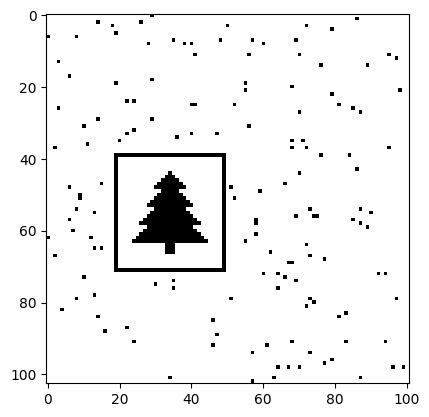

In [4]:
# (The Easter Egg)
import matplotlib.pyplot as plt

display = np.zeros((103,101), dtype=int)
display[*[np.squeeze(i,1) 
          for i in np.hsplit(np.mod(pos+vel*nsecs,[103,101]),
                             2)]] = 1
plt.imshow(display, cmap='gray_r') 